## **Linear Regression — Line of Best Fit**

### **Equation of the Line**
ŷ = m × x + c  
- ŷ: predicted value  
- x: input feature  
- m: slope of the line  
- c: intercept (where the line crosses the y-axis)

---

### **Slope (m) and Intercept (c)**

**Method 1 (using means):**  
m = Σ[(x - x̄) × (y - ȳ)] / Σ[(x - x̄)²]  
c = ȳ - m × x̄

**Method 2 (using sums):**  
m = [n × Σ(xy) - Σx × Σy] / [n × Σ(x²) - (Σx)²]  
c = ȳ - m × x̄

Where:  
- x̄ = mean of x  
- ȳ = mean of y  
- n = number of data points  
- Σ = summation symbol  
- xy = product of x and y for each data point  
- x² = square of x for each data point

---

### **Error / Residual**
Error = (y - ŷ)²  
- This is the squared difference between actual value (y) and predicted value (ŷ).  
- Squaring ensures that both positive and negative errors contribute positively to the total error.

**Note:**  
Squaring the residuals prevents cancellation of errors and emphasizes larger mistakes more strongly.

# 📘 **Linear Regression Modeling using Scikit-Learn**

### Finding Line of Best Fit for a Small Dataset
---

## **Step 1 — Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Notes:**

* NumPy → numerical computation
* Pandas → data handling
* Matplotlib → visualization
* Scikit-Learn → machine learning models

---

## **Step 2 — Dataset Creation**

In [2]:
data = {
    "x": [1, 2, 4, 6, 8],
    "y": [3, 4, 8, 10, 15]
}

df = pd.DataFrame(data)
df

,x,y
0,1,3
1,2,4
2,4,8
3,6,10
4,8,15


---

## **Step 3 — Data Understanding & Exploration**


In [5]:
# 3.1 Basic Information
print(df.info())
print("++++++++++++")
# 3.2 Statistical Summary
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       5 non-null      int64
 1   y       5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes
None
++++++++++++
              x         y
count  5.000000   5.00000
mean   4.200000   8.00000
std    2.863564   4.84768
min    1.000000   3.00000
25%    2.000000   4.00000
50%    4.000000   8.00000
75%    6.000000  10.00000
max    8.000000  15.00000


**Insights:**

* Small dataset
* Continuous numerical values
* Clear increasing trend between x and y

---

## **Step 4 — Data Visualization**
### **4.1 Scatter Plot of Data**

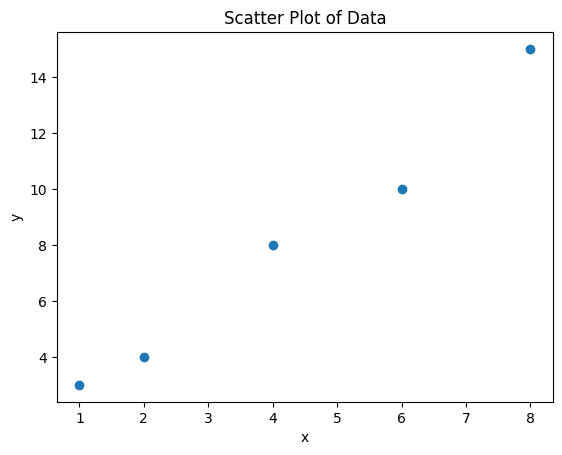

In [6]:
plt.scatter(df["x"], df["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot of Data")
plt.show()

**Observation:**

The data follows a **strong linear pattern**, so **Linear Regression** is an appropriate model.

---

## **Step 5 — Feature & Target Separation**

In [10]:
X = df[["x"]]   # Feature (must be 2D for sklearn)
y = df["y"]     # Target

print(X.head(3))
print(X.shape)
print(y.head(3))
print(y.shape)

   x
0  1
1  2
2  4
(5, 1)
0    3
1    4
2    8
Name: y, dtype: int64
(5,)


---

## **Step 6 — Model Selection**

Based on visualization and data behavior:
> **Chosen Model:** Linear Regression
> **Reason:** Relationship between x and y is approximately linear.

In [11]:
model = LinearRegression()

---

## **Step 7 — Model Training**
### What `model.fit()` Does?

The `model.fit()` function is used to **train a machine learning model** on given data.  
- **Inputs:** Training features (`X`) and labels (`y`).  
- **Process:** The model learns patterns by adjusting its internal parameters to minimize error.  
- **Output:** A trained model that can make predictions on new, unseen data.  

In short, `model.fit()` is the step where the model *learns* from data.


In [12]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


---

## **Step 8 — Extract Model Parameters (Best Fit Line)**

In [13]:
m = model.coef_[0]
c = model.intercept_

print("Slope (m):", m)
print("Intercept (c):", c)

print("\nBest Fit Equation:")
print(f"y = {m:.4f}x + {c:.4f}")

Slope (m): 1.6768292682926826
Intercept (c): 0.9573170731707323

Best Fit Equation:
y = 1.6768x + 0.9573


This output should match closely with:
> **y = 1.68x + 0.94**

---

## **Step 9 — Model Prediction**

In [16]:
y_pred = model.predict(X)
print(y_pred)

[ 2.63414634  4.31097561  7.66463415 11.01829268 14.37195122]


---

## **Step 10 — Model Evaluation**

### **10.1 Mean Squared Error (MSE)**
**Formula:**
MSE = (1/n) × Σ (yᵢ - ŷᵢ)²

- **Meaning:** MSE measures the average squared difference between actual values (yᵢ) and predicted values (ŷᵢ).  
- A lower MSE means the model’s predictions are closer to the true values.

---

### **10.2 R² Score (Coefficient of Determination)**
**Formula:**
R² = 1 - [ Σ (yᵢ - ŷᵢ)² / Σ (yᵢ - ȳ)² ]

- **Meaning:** R² shows how well the model explains the variance in the data.  
- R² = 1 → perfect fit  
- R² = 0 → model explains nothing beyond the mean  
- R² < 0 → model performs worse than predicting the mean

---

### **Note on Classification Metrics**
In this scenario, we are solving a **regression problem** (predicting continuous values).  
That’s why we use **MSE** and **R²** instead of classification metrics.  

- **Classification metrics** (Accuracy, Precision, Recall, F1 Score) are only used when the task is to **categorize data into discrete classes** (e.g., spam vs. not spam, disease vs. no disease, image recognition of cats vs. dogs).  
- Since regression outputs continuous numbers (like predicting house prices, stock values, or flower measurements), classification metrics are not meaningful here.

---

### **Classification Metrics (for classification problems only)**

### Accuracy
Accuracy = (TP + TN) / (TP + TN + FP + FN)

### Precision
Precision = TP / (TP + FP)

### Recall (Sensitivity)
Recall = TP / (TP + FN)

### F1 Score
F1 = 2 × (Precision × Recall) / (Precision + Recall)


In [26]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)
print("++++++++++++")

r2 = r2_score(y, y_pred)
print("R2 Score:", r2)

# Classification metrics (only if y are class labels, not continuous values)
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# print("Accuracy:", accuracy_score(y, y_pred))
# print("Precision:", precision_score(y, y_pred, average='macro'))
# print("Recall:", recall_score(y, y_pred, average='macro'))
# print("F1 Score:", f1_score(y, y_pred, average='macro'))

Mean Squared Error: 0.3548780487804869
++++++++++++
R2 Score: 0.9811235080435912


---

## **Step 11 — Visualizing Best Fit Line**

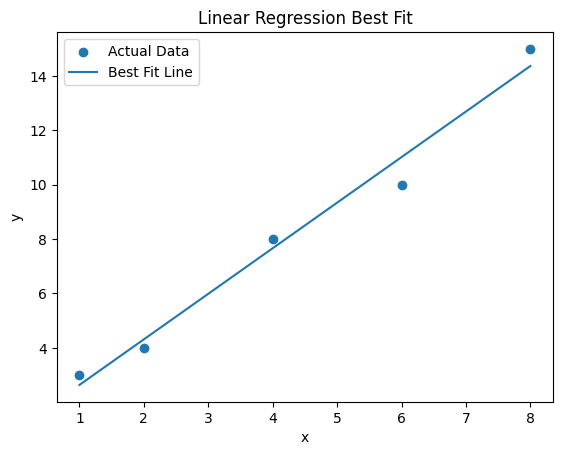

In [19]:
plt.scatter(df["x"], df["y"], label="Actual Data")
plt.plot(df["x"], y_pred, label="Best Fit Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Best Fit")
plt.legend()
plt.show()

---

## **Step 12 — Residual Analysis**

In [29]:
df["y_pred"] = y_pred
residuals = y - y_pred
df["Residuals (yᵢ - ŷᵢ)"] = residuals
df["Residuals² (yᵢ - ŷᵢ)²"] = residuals*residuals
df

,x,y,Residuals,y_pred,Residuals (yᵢ - ŷᵢ),Residuals² (yᵢ - ŷᵢ)²
0,1,3,0.365854,2.634146,0.365854,0.133849
1,2,4,-0.310976,4.310976,-0.310976,0.096706
2,4,8,0.335366,7.664634,0.335366,0.112470
3,6,10,-1.018293,11.018293,-1.018293,1.036920
4,8,15,0.628049,14.371951,0.628049,0.394445


### **12.1 Residual Plot**

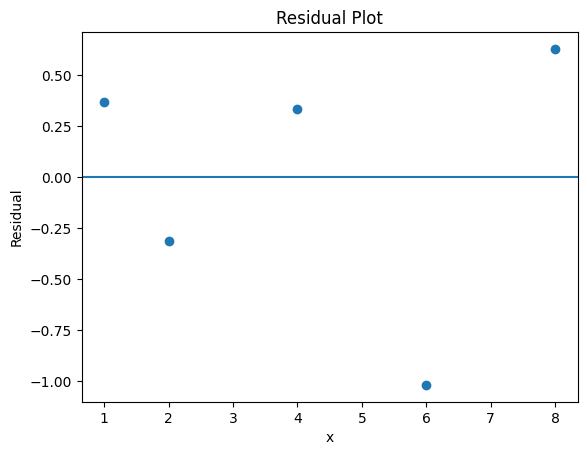

In [ ]:
plt.scatter(df["x"], residuals)
plt.axhline(0) # axhline is used to draw a horizontal line across a plot
plt.xlabel("x")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

---

# Q. Find the line of best-fit for the following data points using Least Square Method (LSM)

Data points:
(1, 3), (2, 4), (4, 8), (6, 10), (8, 15)

---

## Step 1: Create the Working Table

| x | y  | x − x̄ | y − ȳ | (x − x̄)² | (x − x̄)(y − ȳ) |
| - | -- | ------ | ----- | --------- | --------------- |
| 1 | 3  | -3.2   | -5    | 10.24     | 16              |
| 2 | 4  | -2.2   | -4    | 4.84      | 8.8             |
| 4 | 8  | -0.2   | 0     | 0.04      | 0               |
| 6 | 10 | 1.8    | 2     | 3.24      | 3.6             |
| 8 | 15 | 3.8    | 7     | 14.44     | 26.6            |

Sum of x values = 21
Sum of y values = 40

Number of points = 5

Mean of x (x̄) = 21 / 5 = 4.2
Mean of y (ȳ) = 40 / 5 = 8

Sum of (x − x̄)² = 32.8
Sum of (x − x̄)(y − ȳ) = 55

---

## Step 2: Compute the Slope (m)

Slope m =
Sum of (x − x̄)(y − ȳ) divided by Sum of (x − x̄)²

m = 55 / 32.8
m = 1.68

---

## Step 3: Compute the Intercept (c)

c = ȳ − m × x̄
c = 8 − 1.68 × 4.2
c = 8 − 7.056
c = 0.94

---

## Final Best Fit Line

Best fit equation:

y = 1.68x + 0.94

---

## Step 4: Predictions Using the Model

| x | Actual y | Predicted y |
| - | -------- | ----------- |
| 1 | 3        | 2.62        |
| 2 | 4        | 4.30        |
| 4 | 8        | 7.66        |
| 6 | 10       | 11.02       |
| 8 | 15       | 14.38       |

---

## Step 5: Error Measurement Using Mean Squared Error (MSE)

First compute errors:

| x | y  | Predicted y | Error (y − y_pred) | Error² |
| - | -- | ----------- | ------------------ | ------ |
| 1 | 3  | 2.62        | 0.38               | 0.1444 |
| 2 | 4  | 4.30        | -0.30              | 0.09   |
| 4 | 8  | 7.66        | 0.34               | 0.1156 |
| 6 | 10 | 11.02       | -1.02              | 1.0404 |
| 8 | 15 | 14.38       | 0.62               | 0.3844 |

Sum of squared errors = 1.775

Mean Squared Error (MSE) =
Total squared error / number of points

MSE = 1.775 / 5
MSE = 0.355

---

## Conclusion

The Least Squares Method produces the line:

y = 1.68x + 0.94

This line minimizes the Mean Squared Error, and therefore it is the optimal best-fit line for the given data.

---

---

# 🧠 **Key Concept**

> **The Least Squares Method already produces the mathematically optimal line.**
> There is **no better line** (in the least-squares sense) than the one you computed:

**y = 1.68x + 0.94**

This line **already minimizes the total squared error**.

So the short answer is:

* ❌ You do **not** need to update it gradually
* ✅ The current equation is already the best possible under LSM

Now let’s explain *why*, in a way students will truly understand.

---

## 📐 1. **What does “best fit” actually mean?**

Least Squares Method chooses **m** and **c** such that this quantity is minimized:

**E(m, c) = Σ [ yi − (m·xi + c) ]²**

This is called the **Sum of Squared Errors (SSE)**.

You are minimizing a surface shaped like a **bowl**:

```
   start
     ↓
    •
      •
        •
          •
            •
              •  ← minimum
```

That lowest point is found **analytically** by solving:

**∂E / ∂m = 0**
**∂E / ∂c = 0**

When you used:

**m = Σ (x − x̄)(y − ȳ) / Σ (x − x̄)²**
**c = ȳ − m·x̄**

you **solved those equations exactly**.

So your line is not “a guess” —
it is the **global optimum**.

---

## 🧮 2. **Could we improve it gradually using error?**

You *could* use an iterative method like **Gradient Descent**, where you start with random **m, c** and update:

**m_new = m_old − α · (∂E / ∂m)**
**c_new = c_old − α · (∂E / ∂c)**

This would **slowly approach** the same solution:

**m ≈ 1.68**
**c ≈ 0.94**

But:

> 🎯 LSM already gives you the **final answer in one step**

So iterative improvement is **educational**, not necessary.

---

## 📊 3. **Is the error already minimized?**

Yes.
Your computed residual sum:

**Σ (y − ŷ)² = 1.775**

If you slightly change **m** or **c**, this value **increases**.

That’s the defining property of a minimum.

---

## 🧩 **4. Why is the error not zero then?**

Because the data itself is **not perfectly linear**.

No straight line can pass through all points:

(1, 3), (2, 4), (4, 8), (6, 10), (8, 15)

So the best you can do is minimize the total error — not eliminate it.

This is a powerful teaching insight:

> **Error comes from the data, not from the method.**

---

## 🧪 **5. When would we *update* the model?**

We only update the model if:

| Situation                                                         | Action                 |
| ----------------------------------------------------------------- | ---------------------- |
| New data arrives                                                  | Recompute best fit     |
| We change loss function (e.g., absolute error instead of squared) | New optimal line       |
| We add constraints                                                | New solution           |
| We move to nonlinear model                                        | Different optimization |

But with the same data and squared error,
**your equation is final and optimal.**

---
---

## 🔽 **1. Understanding the Error Surface**

When we talk about minimizing the error
**E(m, c) = Σ [ yi − (m·xi + c) ]²**,
we are minimizing a **surface in 3D space** where:

* one axis is **m** (slope),
* one axis is **c** (intercept),
* and the height is the **error value E**.

This surface always looks like a **bowl (convex surface)**.

### Correct Shape of the Error Surface

```
        •
      •   •
    •       •
  •           •
 •               •
   •           •
      •     •
         •   ← global minimum (lowest point)
```

Now the minimum is correctly shown at the **bottom of the bowl**.

### What This Means

* Every possible pair (m, c) gives one error value E.
* The surface has **only one lowest point**.
* That point corresponds to:

  **m = 1.68**
  **c = 0.94**

So the equation:

**y = 1.68x + 0.94**

is the **unique global optimum** — not just a good guess, but the best possible solution.

---

## 🧭 **2. Why Least Squares Finds This Minimum Exactly**

Least Squares does not “search” randomly.
It **solves the equations of the surface directly**:

* ∂E / ∂m = 0
* ∂E / ∂c = 0

These two equations locate the **lowest point of the bowl exactly**.
That is why LSM gives the answer in one step.

---

## 🧮 **3.Why Gradient Descent Is Slower (But Educational)**

Gradient Descent imagines a particle rolling down the bowl:

```
   start
     ↓
    •
      •
        •
          •
            •
              •  ← minimum
```

It keeps moving in the direction of steepest descent until it reaches the bottom.

It will **always converge to the same minimum**:

**m = 1.68**, **c = 0.94**

LSM simply **jumps directly to the bottom** by solving the math.

---

## 🧠 Key Insight:

The key reason LSM is so powerful:

> The error surface for linear regression is **convex**,
> meaning it has **one and only one minimum**.

So:

* No local traps
* No alternative better solutions
* No need for gradual improvement

Once the minimum is reached, **no further improvement is mathematically possible**.

---



---

# **1. What is Least Squares Method (LSM)?**

### **Definition**

**Least Squares Method (LSM)** is a mathematical optimization technique used to find the parameters of a model (such as slope and intercept of a line) that **minimize the total squared difference between actual values and predicted values.**

In simple words:

> **LSM finds the line that makes the total prediction error as small as possible.**

That error is measured by:

**Total Squared Error = Σ (y − ŷ)²**

LSM chooses the values of **m** and **c** such that this total squared error becomes minimum.

---

# **2. What kinds of problems use LSM?**

LSM is mainly used for:

| Problem Type      | Examples                                          |
| ----------------- | ------------------------------------------------- |
| Regression        | Predicting house prices, temperature, stock value |
| Curve fitting     | Finding best curve through data                   |
| Signal processing | Noise reduction                                   |
| Data modeling     | Estimating unknown relationships                  |

LSM is **not** for classification directly.
Classification uses different loss functions.

---

# **3. How are ML problems categorized?**

| Category                 | What it Predicts  | Examples                       |
| ------------------------ | ----------------- | ------------------------------ |
| Regression               | Continuous values | Price, height, temperature     |
| Classification           | Class labels      | Spam/Not spam, disease/healthy |
| Clustering               | Grouping          | Customer segments              |
| Dimensionality Reduction | Fewer features    | PCA                            |
| Time Series              | Sequential values | Stock, weather                 |
| Anomaly Detection        | Unusual patterns  | Fraud                          |

---

# **4. What are the main regression methods?**

### **Classical Regression Methods**

| Method                | Used for                   |
| --------------------- | -------------------------- |
| Linear Regression     | Linear relationship        |
| Polynomial Regression | Curved relationship        |
| Ridge Regression      | Linear with regularization |
| Lasso Regression      | Feature selection          |
| Elastic Net           | Ridge + Lasso              |
| Nonlinear Regression  | Complex patterns           |

### **Modern ML Regression Models**

| Model                    | Type           |
| ------------------------ | -------------- |
| Decision Tree Regressor  | Nonlinear      |
| Random Forest Regressor  | Ensemble       |
| Support Vector Regressor | Kernel-based   |
| Neural Networks          | Deep learning  |
| KNN Regressor            | Instance-based |

---

# **5. Are your formulas only for LSM?**

Yes.
Those formulas for **m** and **c** come from **solving the Least Squares optimization problem for linear regression**.

They are called:

> **Normal Equation Solution of Linear Regression**

They are **specific to LSM + Linear Regression**.

Other regression models do **not** use these formulas.

---

# **6. Can we use MSE in LSM?**

Yes — absolutely.

In fact:

**MSE = (1/n) × Σ (y − ŷ)²**

LSM minimizes **Σ (y − ŷ)²**
Minimizing Σ (y − ŷ)² is **exactly equivalent** to minimizing MSE.

The only difference:

* Σ (y − ŷ)² → total error
* MSE → average error

The location of the minimum is the same.

---

# **7. Why do we usually use (y − ŷ)²?**

Because of **three powerful reasons:**

### **1️⃣ Squaring avoids cancellation**

Positive and negative errors cancel if we don't square them.

### **2️⃣ Squaring penalizes large errors more**

Big mistakes are punished strongly, making the model more stable.

### **3️⃣ Squared error is mathematically convenient**

Its derivative is smooth and easy to optimize.
That is why LSM has a **closed-form solution**.

---

# **8. Why not use absolute error instead?**

We can — but then:

| Loss Function  | Optimization               |
| -------------- | -------------------------- |
| Squared error  | Easy, closed-form solution |
| Absolute error | No closed-form solution    |
| Huber loss     | Robust but complex         |

LSM exists **because squared error makes optimization tractable**.

---

# **9. Summary for Teaching**

| Concept       | Explanation                              |
| ------------- | ---------------------------------------- |
| LSM           | Minimizes total squared error            |
| Regression    | Predicts continuous values               |
| Your formulas | Closed-form solution of LSM              |
| MSE           | Normalized version of LSM error          |
| Why squared   | Prevents cancellation + math convenience |

---
